# 江南江北光伏出力预测与实际数据&云量辐射气象数据的关系
气象数据说明：
- 分别来自三家不同的公司ANT、OBS、CLD
- 江南以苏州4月的气象数据为例，格点为1h
- 江北以盐城4月的气象数据为例，格点为1h
   
光伏出力数据说明：
- 分为日前预测出力与实际运行出力2类
- 取1h內4个统计值的平均，即每天有24个数据  

## 数据读取与预处理  

### 气象数据

In [1]:
import pandas as pd

SU_ANT = pd.read_excel('/Users/huyang/Desktop/4月江南气象/ANT苏州4月.xlsx',
                       usecols=['日期', '小时','辐射(W/m²)', '气温(°C)','云量(%)']).set_index(['日期', '小时'])

SU_OBS = pd.read_excel('/Users/huyang/Desktop/4月江南气象/OBS苏州4月.xlsx',
                       usecols=['日期', '小时','辐射(W/m²)', '气温(°C)','云量(%)']).set_index(['日期', '小时'])

SU_CLD = pd.read_excel('/Users/huyang/Desktop/4月江南气象/CLD苏州4月.xlsx',
                       usecols=['日期', '小时','辐射(W/m²)', '气温(°C)','云量(%)']).set_index(['日期', '小时'])

YAN_ANT = pd.read_excel('/Users/huyang/Desktop/4月江北气象/ANT盐城4月.xlsx',
                       usecols=['日期', '小时','辐射(W/m²)', '气温(°C)','云量(%)']).set_index(['日期', '小时'])

YAN_OBS = pd.read_excel('/Users/huyang/Desktop/4月江北气象/OBS盐城4月.xlsx',
                       usecols=['日期', '小时','辐射(W/m²)', '气温(°C)','云量(%)']).set_index(['日期', '小时'])

YAN_CLD = pd.read_excel('/Users/huyang/Desktop/4月江北气象/CLD盐城4月.xlsx',
                       usecols=['日期', '小时','辐射(W/m²)', '气温(°C)','云量(%)']).set_index(['日期', '小时'])
SU_ANT

辐射(W/m²)  气温(°C)   云量(%)
日期         小时                             
2026/04/01 01:00     0.000   9.784  79.276
           02:00     0.000   9.985  89.733
           03:00     0.000  10.454  98.645
           04:00     0.000  10.592  99.933
           05:00     0.795  10.741  99.870
...                    ...     ...     ...
2026/04/30 20:00     0.594  14.405   0.000
           21:00     0.000  13.910   0.000
           22:00     0.000  13.466   0.000
           23:00     0.000  13.146   0.000
           24:00     0.000  12.864   0.000

[720 rows x 3 columns]

### 光伏出力数据  
- 截取想要的数据列并合并
- 计算出小时平均值与气象数据的24格点统一  

In [56]:
import pandas as pd

file_paths = [f'/Users/huyang/Desktop/2026年4月可视化图表/江苏现货价格可视化图表202604{i:02d}.xlsx' for i in range(1, 31)]
all_dfs = []

for i, file_path in enumerate(file_paths, start=1):
    df = pd.read_excel(
        file_path,
        sheet_name='电网运行信息',
        usecols='F,I,J,AJ,AK',
        skiprows=2,  # 跳过前2行
        header=None   # 不将任何行作为列名，因为数据从第3行开始
    )
    
    # 统一列名
    df.columns = ['时刻', '预测光伏江南', '预测光伏江北', '实际光伏江南', '实际光伏江北']

    df.dropna(subset=['时刻'], inplace=True)
    df['时刻'] = df['时刻'].astype(str).str.strip().str[-8:]  # 取最后8个字符
    df['时刻'] = df['时刻'].str[:5]  # 截取HH:MM

    # 去除均值行
    df = df[~df['时刻'].str.contains('均值|平均|avg', case=False, na=False)]
    
    # 设置多层索引（表号, 时刻）
    df['日期'] = f'2026/04/{i:02d}'
    df.set_index(['日期', '时刻'], inplace=True)
    
    all_dfs.append(df)

result_df = pd.concat(all_dfs)
result_df

预测光伏江南  预测光伏江北  实际光伏江南  实际光伏江北
日期         时刻                                   
2026/04/01 00:15     0.0     0.0    0.25    7.18
           00:30     0.0     0.0    0.47    7.27
           00:45     0.0     0.0    0.23    7.32
           01:00     0.0     0.0    0.26    7.37
           01:15     0.0     0.0    0.27    7.36
...                  ...     ...     ...     ...
2026/04/30 23:00     0.0     0.0    0.13    6.65
           23:15     0.0     0.0    0.12    7.07
           23:30     0.0     0.0    0.12    7.09
           23:45     0.0     0.0    0.17    6.82
           00:00     0.0     0.0    0.15    6.95

[2880 rows x 4 columns]

In [57]:
# 重置索引，准备分组
result = result_df.reset_index()

# 计算小时组：每4个时刻一组，用该组最后一个时刻的整点命名
# 时刻列表顺序：00:15, 00:30, 00:45, 01:00, 01:15, ..., 23:15, 23:30, 23:45, 00:00
# 00:15-01:00 → 01:00
# 01:15-02:00 → 02:00
# ...
# 23:15-00:00 → 24:00

def get_hour_group(time_str):
    h, m = map(int, time_str.split(':'))
    # 将时刻转换为从00:15开始计的序号（00:15=1, 00:30=2, ..., 00:00=96）
    if h == 0 and m == 0:
        seq = 96  # 00:00是第96个时刻
    else:
        seq = h * 4 + m // 15  # 正常时刻的序号
    
    # 计算所属组的序号（每4个一组，向上取整）
    group_seq = (seq + 3) // 4  # 1-4→1, 5-8→2, ..., 93-96→24
    
    # 组序号对应的整点，第24组特殊处理为24:00
    if group_seq == 24:
        return '24:00'
    else:
        return f'{group_seq:02d}:00'

result['小时'] = result['时刻'].apply(get_hour_group)

# 按日期和小时组分组，计算平均值
hourly_mean = result.groupby(['日期', '小时'])[['预测光伏江南', '预测光伏江北', '实际光伏江南', '实际光伏江北']].mean()
# 设置索引名称
hourly_mean.index.names = ['日期', '小时']
hourly_mean.to_excel('/Users/huyang/Desktop/新能源出力与气象的关系/每小时光伏出力.xlsx')
hourly_mean


预测光伏江南  预测光伏江北  实际光伏江南  实际光伏江北
日期         小时                                   
2026/04/01 01:00  0.0000   0.000  0.3025  7.2850
           02:00  0.0000   0.000  0.3900  7.1350
           03:00  0.0000   0.000  0.3175  7.3275
           04:00  0.0000   0.000  0.3075  7.1075
           05:00  0.0000   0.000  0.3950  7.2575
...                  ...     ...     ...     ...
2026/04/30 20:00  0.0025   0.015  0.0800  6.1400
           21:00  0.0000   0.000  0.1100  7.1275
           22:00  0.0000   0.000  0.1150  6.7600
           23:00  0.0000   0.000  0.1275  6.9375
           24:00  0.0000   0.000  0.1400  6.9825

[720 rows x 4 columns]

### 合并DF并保存

In [59]:
South_Atmospheric_df = [SU_ANT,SU_OBS,SU_CLD]
South_Atmospheric_names = ['SU_ANT', 'SU_OBS', 'SU_CLD']
for south_weather_df,name in zip(South_Atmospheric_df,South_Atmospheric_names):
    combined_df = hourly_mean.join(south_weather_df, how='inner')
    combined_df.to_excel('/Users/huyang/Desktop/新能源出力与气象的关系/江南（苏州）光伏气象数据/'+f'{name}' + '苏州光伏气象数据.xlsx')

North_Atmospheric_df = [YAN_ANT,YAN_OBS,YAN_CLD]
North_Atmospheric_names = ['YAN_ANT','YAN_OBS','YAN_CLD']
for north_weather_df,name in zip(North_Atmospheric_df,North_Atmospheric_names):
    combined_df = hourly_mean.join(north_weather_df, how='inner')
    combined_df.to_excel('/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）光伏气象数据/'+f'{name}' + '盐城光伏气象数据.xlsx')

## 散点图预览    
以预测光伏出力&辐射数据为例绘制散点图，计算相关系数、趋势  

### 预测光伏江南 & 苏州辐射

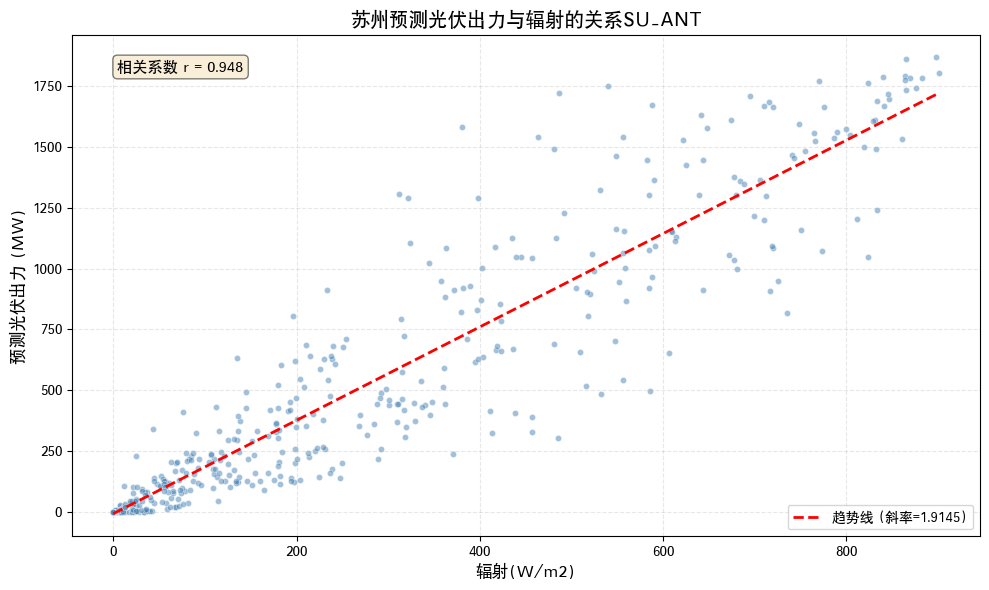

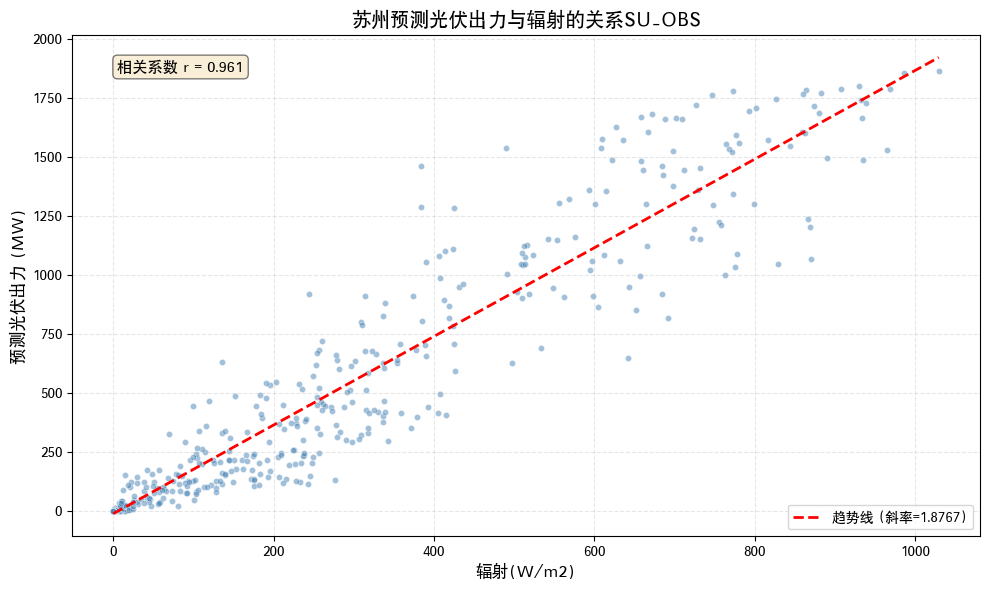

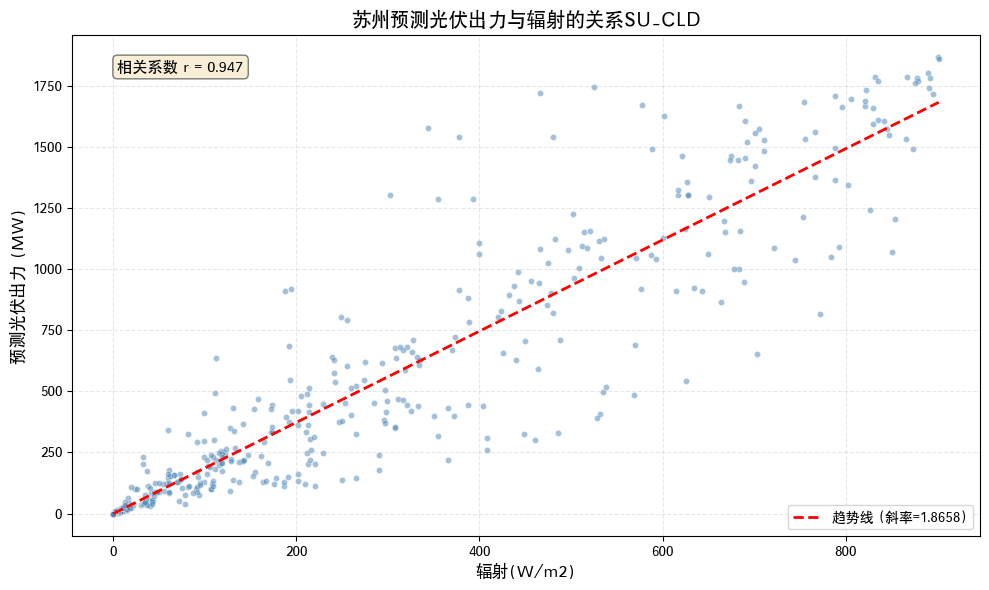

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

file_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江南（苏州）光伏气象数据/'
south_df_names = ['SU_ANT', 'SU_OBS', 'SU_CLD']
save_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江南（苏州）光伏气象数据/'
os.makedirs(save_path, exist_ok=True)
for name in south_df_names:
    df = pd.read_excel(file_path + f'{name}' + '苏州光伏气象数据.xlsx')
    plt.figure(figsize=(10, 6))
    plt.scatter(df['辐射(W/m²)'], df['预测光伏江南'], 
            alpha=0.5,        # 透明度
            s=20,             # 点的大小
            c='steelblue',    # 颜色
            edgecolors='white',  # 边缘白色
            linewidth=0.5)
    # 添加趋势线
    z = np.polyfit(df['辐射(W/m²)'], df['预测光伏江南'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df['辐射(W/m²)'])
    plt.plot(x_sorted, p(x_sorted), 'r--', linewidth=2, label=f'趋势线 (斜率={z[0]:.4f})')
    # 添加标签和标题
    plt.xlabel('辐射(W/m2)', fontsize=12)
    plt.ylabel('预测光伏出力 (MW)', fontsize=12)
    plt.title('苏州预测光伏出力与辐射的关系' + f'{name}'  , fontsize=14, fontweight='bold')
    # 添加网格
    plt.grid(True, alpha=0.3, linestyle='--')
    # 显示图例
    plt.legend(fontsize=10)
    # 显示相关系数
    correlation = df['辐射(W/m²)'].corr(df['预测光伏江南'])
    plt.text(0.05, 0.95, f'相关系数 r = {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


    plt.tight_layout()
    plt.savefig(f'{save_path}'+ f'{name}' + '苏州预测光伏出力与辐射的关系'+'.png', dpi=150, bbox_inches='tight')
    plt.show()

### 预测光伏江北 & 盐城辐射

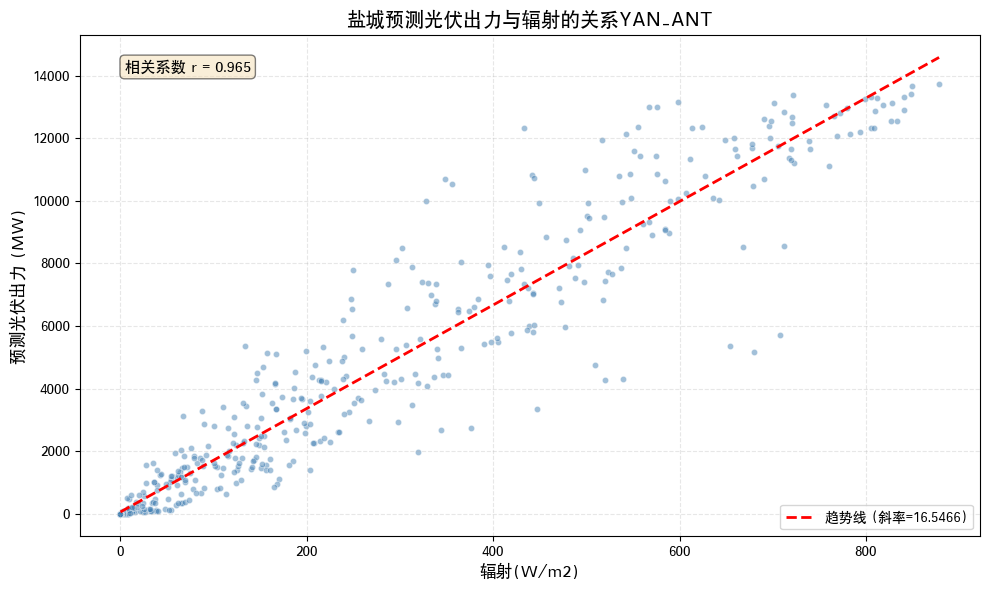

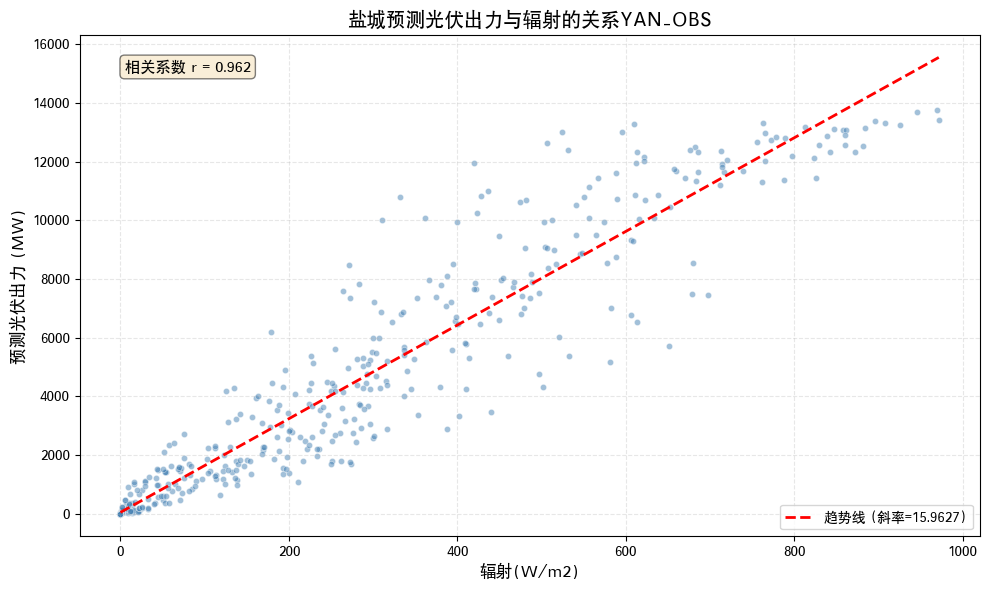

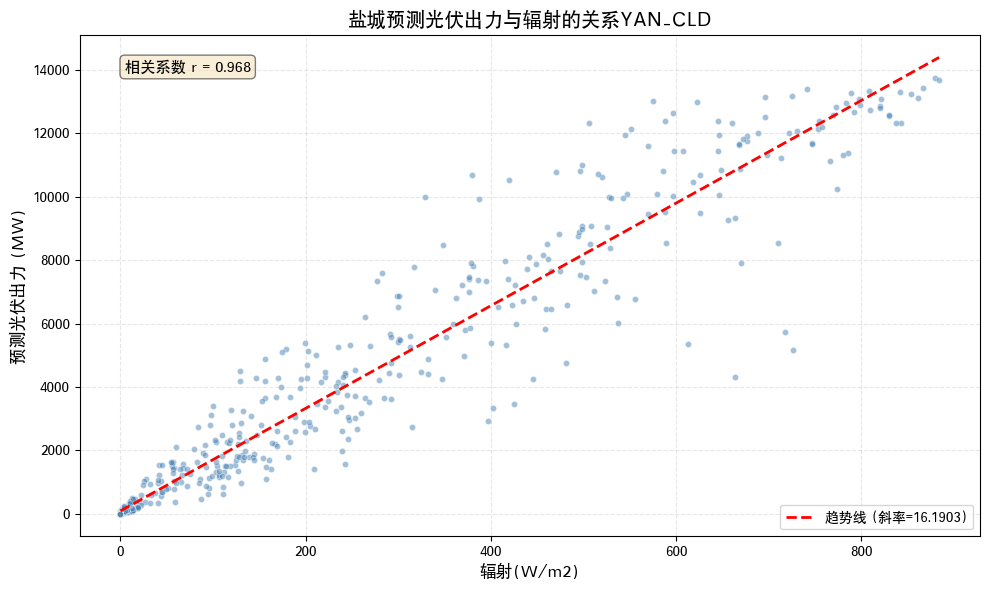

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

file_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）光伏气象数据/'
north_df_names = ['YAN_ANT', 'YAN_OBS', 'YAN_CLD']
save_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）光伏气象数据/'
os.makedirs(save_path, exist_ok=True)
for name in north_df_names:
    df = pd.read_excel(file_path + f'{name}' + '盐城光伏气象数据.xlsx')
    plt.figure(figsize=(10, 6))
    plt.scatter(df['辐射(W/m²)'], df['预测光伏江北'], 
            alpha=0.5,        # 透明度
            s=20,             # 点的大小
            c='steelblue',    # 颜色
            edgecolors='white',  # 边缘白色
            linewidth=0.5)
    # 添加趋势线
    z = np.polyfit(df['辐射(W/m²)'], df['预测光伏江北'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df['辐射(W/m²)'])
    plt.plot(x_sorted, p(x_sorted), 'r--', linewidth=2, label=f'趋势线 (斜率={z[0]:.4f})')
    # 添加标签和标题
    plt.xlabel('辐射(W/m2)', fontsize=12)
    plt.ylabel('预测光伏出力 (MW)', fontsize=12)
    plt.title('盐城预测光伏出力与辐射的关系' + f'{name}' , fontsize=14, fontweight='bold')
    # 添加网格
    plt.grid(True, alpha=0.3, linestyle='--')
    # 显示图例
    plt.legend(fontsize=10)
    # 显示相关系数
    correlation = df['辐射(W/m²)'].corr(df['预测光伏江北'])
    plt.text(0.05, 0.95, f'相关系数 r = {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f'{save_path}'+ f'{name}' + '盐城预测光伏出力与辐射的关系'+'.png', dpi=150, bbox_inches='tight')
    plt.show()

### 预测光伏江北 & 盐城云量   
***注意***：夜间无论云量是多少光伏出力都近似于0，计算相关性时应该将夜间数据去除  

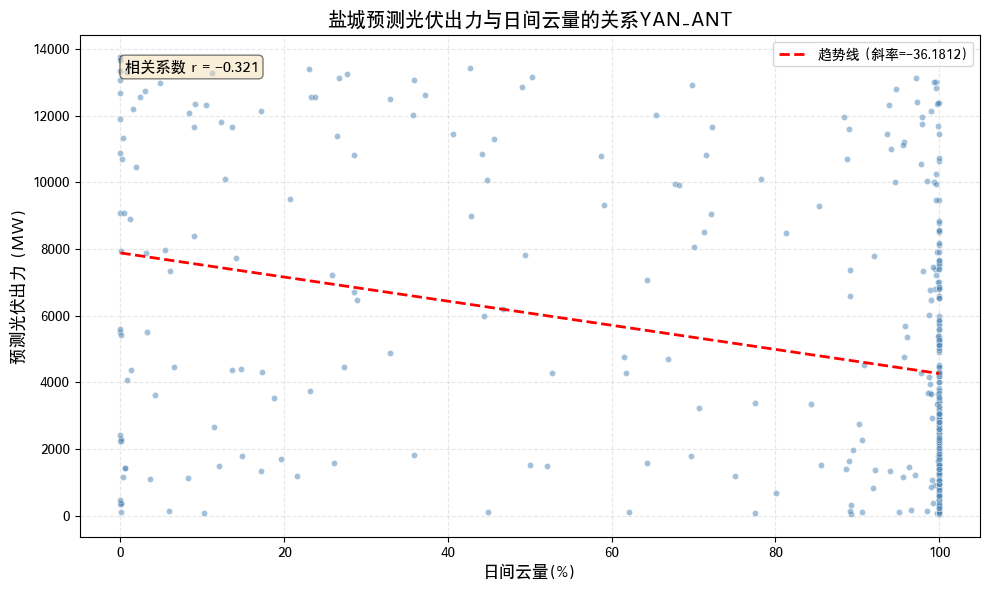

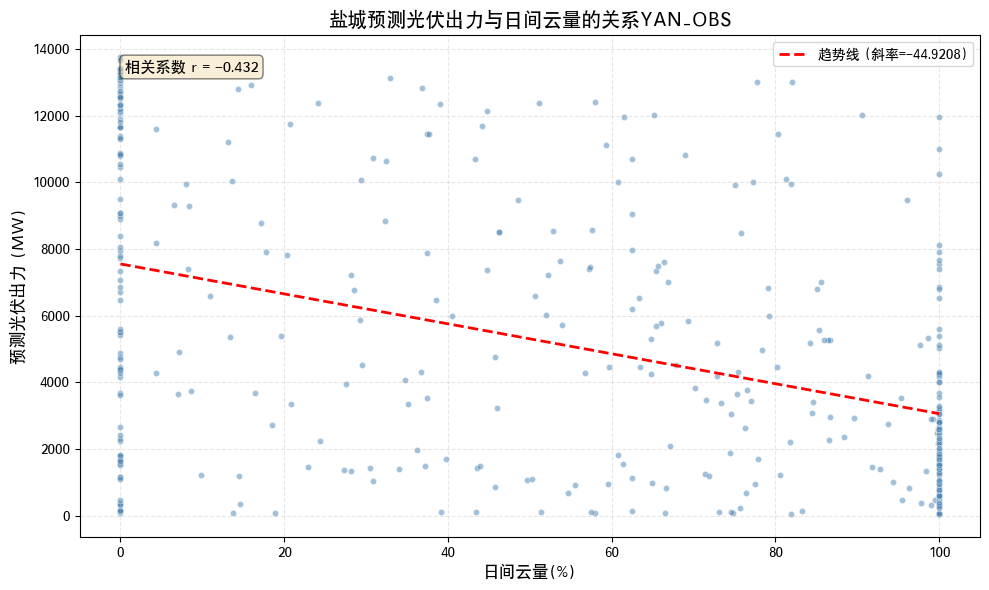

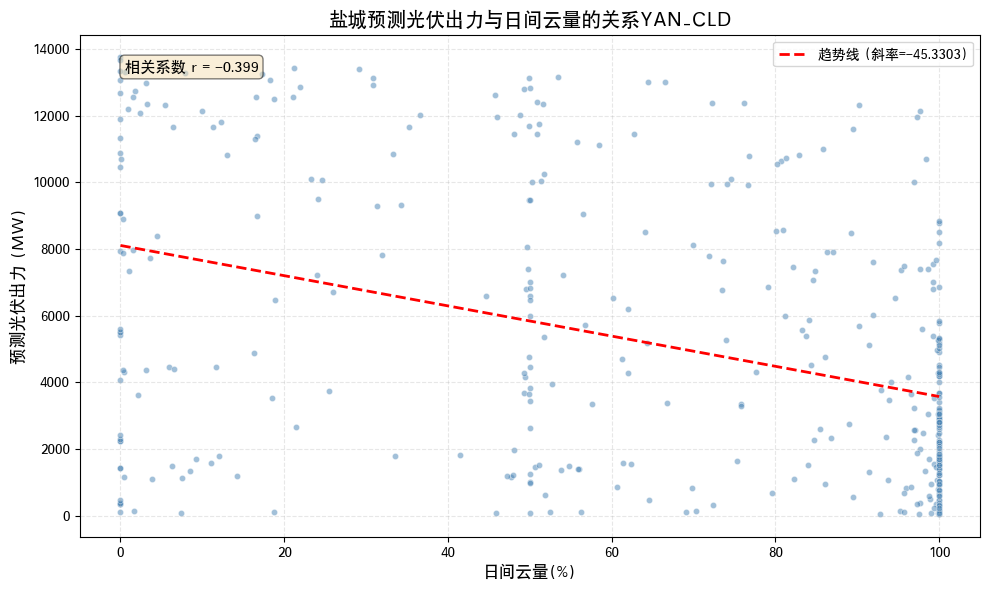

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

file_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）光伏气象数据/'
north_df_names = ['YAN_ANT', 'YAN_OBS', 'YAN_CLD']
save_path = '/Users/huyang/Desktop/新能源出力与气象的关系/江北（盐城）光伏气象数据/'
os.makedirs(save_path, exist_ok=True)
for name in north_df_names:
    df = pd.read_excel(file_path + f'{name}' + '盐城光伏气象数据.xlsx',index_col=[0, 1])

    # 提取日间云量数据
    hour = df.index.get_level_values('小时').str[:2].astype(int)
    day_data = df[(hour >= 6) & (hour <= 18)]
    
    plt.figure(figsize=(10, 6))
    plt.scatter(day_data['云量(%)'], day_data['预测光伏江北'], 
            alpha=0.5,        # 透明度
            s=20,             # 点的大小
            c='steelblue',    # 颜色
            edgecolors='white',  # 边缘白色
            linewidth=0.5)
    # 添加趋势线
    z = np.polyfit(day_data['云量(%)'], day_data['预测光伏江北'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(day_data['云量(%)'])
    plt.plot(x_sorted, p(x_sorted), 'r--', linewidth=2, label=f'趋势线 (斜率={z[0]:.4f})')
    # 添加标签和标题
    plt.xlabel('日间云量(%)', fontsize=12)
    plt.ylabel('预测光伏出力 (MW)', fontsize=12)
    plt.title('盐城预测光伏出力与日间云量的关系' + f'{name}' , fontsize=14, fontweight='bold')
    # 添加网格
    plt.grid(True, alpha=0.3, linestyle='--')
    # 显示图例
    plt.legend(fontsize=10)
    # 显示相关系数
    correlation = day_data['云量(%)'].corr(day_data['预测光伏江北'])
    plt.text(0.05, 0.95, f'相关系数 r = {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f'{save_path}'+ f'{name}' + '盐城预测光伏出力与日间云量的关系'+'.png', dpi=150, bbox_inches='tight')
    plt.show()

### 问题：6点-18点日间云量（%）与光伏出力的散点图几乎毫无规律，相关性为负弱相关  
分析原因：
1.同云“总量”，云“位置”不同。云量是整个天空的云覆盖百分比，但光伏出力取决于“云有没有挡住太阳”。   
2.同云量云类型不同，透光度不同。高层卷云、低层层云/积云  
3.同云量不同时间，太阳高度角不同。  

## 气象要素的日间变化  

### 每日总辐射、平均气温、平均云量的变化折线图

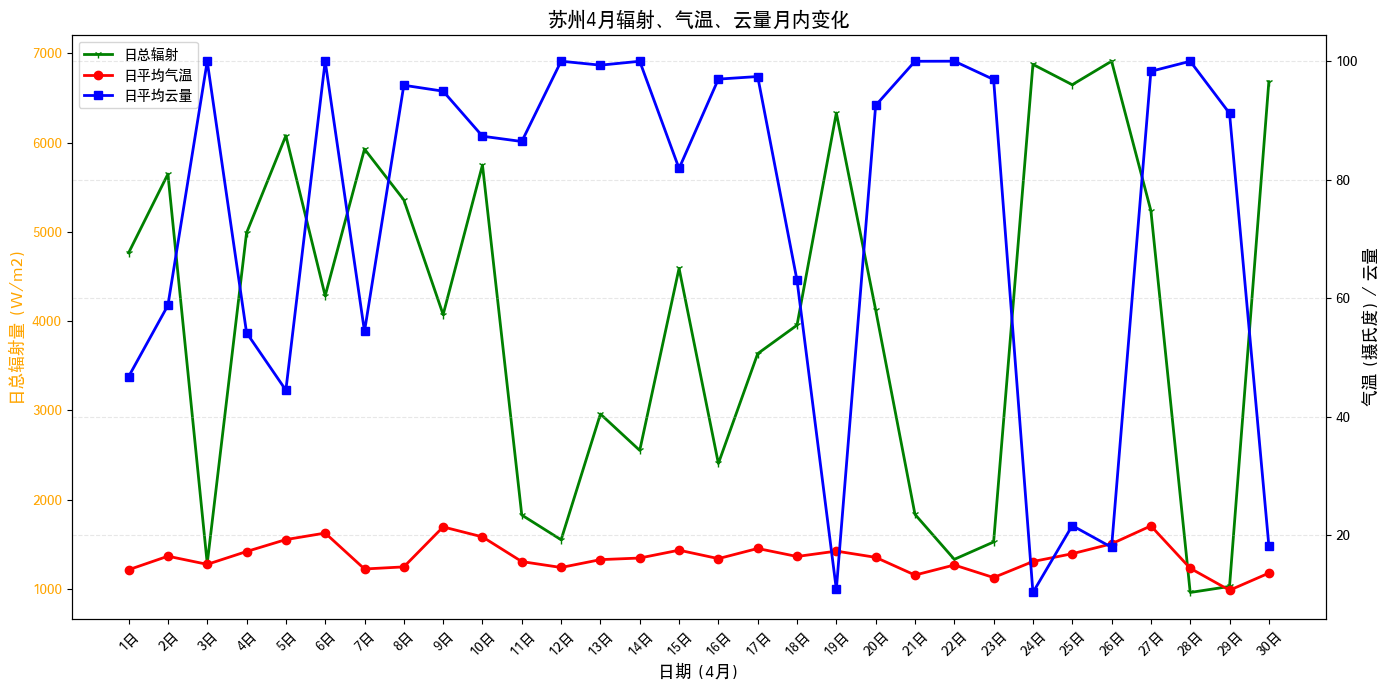

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['font.sans-serif'] = ['Hei']
plt.rcParams['axes.unicode_minus'] = False

# 计算每日统计量
daily_rad = SU_ANT.groupby(level='日期')['辐射(W/m²)'].sum()      # 日总辐射
daily_temp = SU_ANT.groupby(level='日期')['气温(°C)'].mean()           # 日平均气温
daily_cloud = SU_ANT.groupby(level='日期')['云量(%)'].mean()              # 日平均云量

# 创建图表
fig, ax1 = plt.subplots(figsize=(14, 7))

# ★ 左Y轴：辐射（柱状图更直观）
ax1.plot(range(1, 31), daily_rad.values, 'g-1', linewidth=2, markersize=6,label='日总辐射')
ax1.set_xlabel('日期 (4月)', fontsize=12)
ax1.set_ylabel('日总辐射量 (W/m2)', fontsize=12, color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_xticks(range(1, 31))
ax1.set_xticklabels([f'{i}日' for i in range(1, 31)], rotation=45)

# ★ 右Y轴：气温和云量
ax2 = ax1.twinx()
ax2.plot(range(1, 31), daily_temp.values, 'r-o', linewidth=2, markersize=6, label='日平均气温')
ax2.plot(range(1, 31), daily_cloud.values, 'b-s', linewidth=2, markersize=6, label='日平均云量')
ax2.set_ylabel('气温 (摄氏度) / 云量', fontsize=12)
ax2.tick_params(axis='y')

# 图例合并
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('苏州4月辐射、气温、云量月内变化', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### 辐射、气温、云量的相关性分析  

In [19]:
# 统计
r_1 = daily_rad.corr(daily_cloud)
square_r_1 = (r_1**2)*100
r_2 = daily_rad.corr(daily_temp)
square_r_2 = (r_2**2)*100
r_3 = daily_temp.corr(daily_cloud)
square_r_3 = (r_3**2)*100
print(f"辐射与云量{square_r_1:.3f}%相关（{r_1:.3f}）")
print(f"辐射与气温{square_r_2:.3f}%相关（{r_2:.3f}）")
print(f"气温与云量{square_r_3:.3f}%相关（{r_3:.3f}）")

辐射与云量60.417%相关（-0.777）
辐射与气温20.617%相关（0.454）
气温与云量0.139%相关（-0.037）
